# 1. Preparación del entorno

Importamos las librerias necesarias

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import numpy as np
import os, shutil, math
from PIL import Image
import matplotlib.pyplot as plt


Una vez las librerias están cargadas establecemos la ruta de todas la imagenes (esta ruta será variable según quien ejecute el notebook)

In [2]:
RUTA_DATA = r'C:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\Data'
# Detectar clases desde las subcarpetas
clases = sorted([c for c in os.listdir(RUTA_DATA)
                 if os.path.isdir(os.path.join(RUTA_DATA, c))])

Pasamos ahora a examinar el conjunto de datos para identificar las clases disponibles (Sorpresa, Triste, Feliz, Miedo e Ira), también muestro una imagen aleatoria para hacernos a la idea de como son las imágenes

In [3]:
print(f"{'Clases':<12} {'Imágenes por clase':>10}")
conteos = {}
for clase in clases:
    n = len(os.listdir(os.path.join(RUTA_DATA, clase)))
    conteos[clase] = n

total = sum(conteos.values())
for clase, n in conteos.items():
    print(f"{clase:<12} {n:>10}   {n/total*100:>5.1f}%")

print(f"{'TOTAL':<12} {total:>10}")

#Miro el tamaño de una imagen de ejemplo para saber a qué tamaño redimensionar después
primera_clase = clases[0]
primer_archivo = os.listdir(os.path.join(RUTA_DATA, primera_clase))[0]
img_muestra = Image.open(os.path.join(RUTA_DATA, primera_clase, primer_archivo))
print(f"\nTamaño de imagen: {img_muestra.size}")

Clases       Imágenes por clase
Angry             10148    17.2%
Fear               9732    16.5%
Happy             18439    31.2%
Sad               12553    21.2%
Suprise            8227    13.9%
TOTAL             59099

Tamaño de imagen: (48, 48)


Vamos a mostrar un ejemplo de 5 imagenes por clase para ver como son las imagenes con las que vamos a tratar 

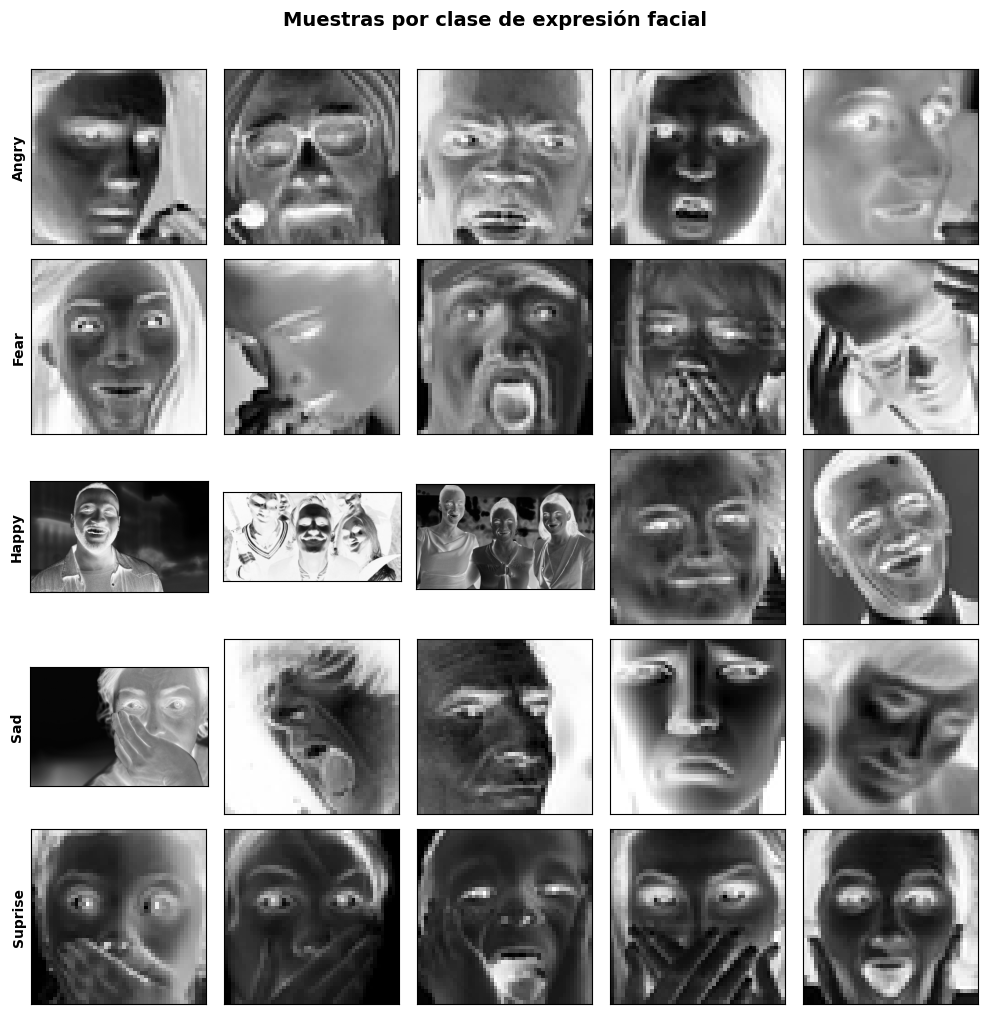

In [4]:
MUESTRAS_POR_CLASE = 5

fig, axes = plt.subplots(len(clases), MUESTRAS_POR_CLASE, figsize=(MUESTRAS_POR_CLASE * 2, len(clases) * 2))

for fila, clase in enumerate(clases):
    carpeta = os.path.join(RUTA_DATA, clase)
    archivos = os.listdir(carpeta)[:MUESTRAS_POR_CLASE]

    for col, archivo in enumerate(archivos):
        img = Image.open(os.path.join(carpeta, archivo)).convert('L')
        ax = axes[fila, col]
        ax.imshow(np.array(img), cmap=plt.cm.binary)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if col == 0:
            ax.set_ylabel(clase, fontsize=10, fontweight='bold')

plt.suptitle('Muestras por clase de expresión facial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Vamos ahora con la preparación del conjunto de dato, para eso creo el Split de train, validacion y test en disco, con 70% para train, 15% para validación y 15% también para test

In [5]:
# Proporciones 70 / 15 / 15
PROP_TRAIN = 0.70
PROP_VAL   = 0.15

RUTA_SPLIT = os.path.join(os.path.dirname(RUTA_DATA), 'Data_split')
RUTA_TRAIN = os.path.join(RUTA_SPLIT, 'train')
RUTA_VAL   = os.path.join(RUTA_SPLIT, 'val')
RUTA_TEST  = os.path.join(RUTA_SPLIT, 'test')

if os.path.exists(RUTA_SPLIT):
    print("Data_split/ ya existe, asique no repetimos la copia")
else:
    np.random.seed(42)

    for clase in clases:
        archivos = np.array(os.listdir(os.path.join(RUTA_DATA, clase)))
        np.random.shuffle(archivos)

        n_total = len(archivos)
        n_train = int(n_total * PROP_TRAIN)
        n_val   = int(n_total * PROP_VAL)

        splits = {
            'train': archivos[:n_train],
            'val'  : archivos[n_train : n_train + n_val],
            'test' : archivos[n_train + n_val:]
        }

        for split_nombre, split_archivos in splits.items():
            destino = os.path.join(RUTA_SPLIT, split_nombre, clase)
            os.makedirs(destino, exist_ok=True)
            for archivo in split_archivos:
                shutil.copy(
                    os.path.join(RUTA_DATA, clase, archivo),
                    os.path.join(destino, archivo)
                )

    print("Data_split/ creada")

# Verificar conteos
print(f"\n{'Clase':<12} {'Train':>7} {'Val':>7} {'Test':>7}")
print("-" * 35)
for clase in clases:
    n_tr = len(os.listdir(os.path.join(RUTA_TRAIN, clase)))
    n_va = len(os.listdir(os.path.join(RUTA_VAL,   clase)))
    n_te = len(os.listdir(os.path.join(RUTA_TEST,  clase)))
    print(f"{clase:<12} {n_tr:>7} {n_va:>7} {n_te:>7}")

Data_split/ ya existe, asique no repetimos la copia

Clase          Train     Val    Test
-----------------------------------
Angry           7103    1522    1523
Fear            6812    1459    1461
Happy          12907    2765    2767
Sad             8787    1882    1884
Suprise         5758    1234    1235


Paso a hacer el procesamiento de los datos, basicamente prepararo las imágenes para que el modelo las pueda consumir durante el entrenamiento

In [6]:
TAMANO_IMG  = (48, 48)
TAMANO_LOTE = 32
NUM_CLASES  = len(clases)

# Generador TRAIN con augmentation y rescaling
generador_train = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 10,         
    width_shift_range  = 0.10,       
    height_shift_range = 0.10,       
    zoom_range         = [0.9, 1.1], 
    horizontal_flip    = True
)

# Generador VAL y TEST: en este caso solo normalización
generador_valtest = ImageDataGenerator(rescale=1./255)

Hemos usado ImageDataGenerator, que es una clase de Keras que hace dos cosas a la vez:  
    - Normaliza las imágenes  
    - Aplica transformaciones aleatorias  

Los parámetros utilizados:   
    - rescale=1./255 : divide cada píxel por 255, después de esto quedan entre 0.0 y 1.0.  
    - rotation_range=10 : rota cada imagen aleatoriamente entre -10° y +10°.  
    - width_shift_range=0.1 : desplaza la imagen horizontalmente hasta un % del ancho.  
    - height_shift_range=0.1 : igual pero vertical.  
    - zoom_range=[0.9, 1.1] : aplica zoom aleatorio entre 90% (alejar) y 110% (acercar).  
    - horizontal_flip=True : espeja la imagen horizontalmente de forma aleatoria, ya que una cara feliz espejada sigue siendo una cara feliz.  

También tenemos el Generador de Validacion y test, pero a este solo le aplicamos normalización  

Ahora pasamos a aplicar las transformaciones y normalización a TRAIN, TEST y VAL, como algún paramétro tenemos que destacar class_mode='categorical', este convierte las etiquetas a formato one-hot. Es decir, en lugar de decir clase 2, dice [0, 0, 1, 0, 0] y el shuffle=True, ya que mezcla las imágenes aleatoriamente en cada época para que el modelo no aprenda el orden

In [7]:
gen_train = generador_train.flow_from_directory(
    RUTA_TRAIN,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = True
)

gen_val = generador_valtest.flow_from_directory(
    RUTA_VAL,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = False
)

gen_test = generador_valtest.flow_from_directory(
    RUTA_TEST,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = False
)


Found 41367 images belonging to 5 classes.
Found 8862 images belonging to 5 classes.
Found 8870 images belonging to 5 classes.


Una vez transformadas la imagenes tenemos que asegurarnos de que la trandormación haya sido exitosa, por eso mostramos un lote aleatorio

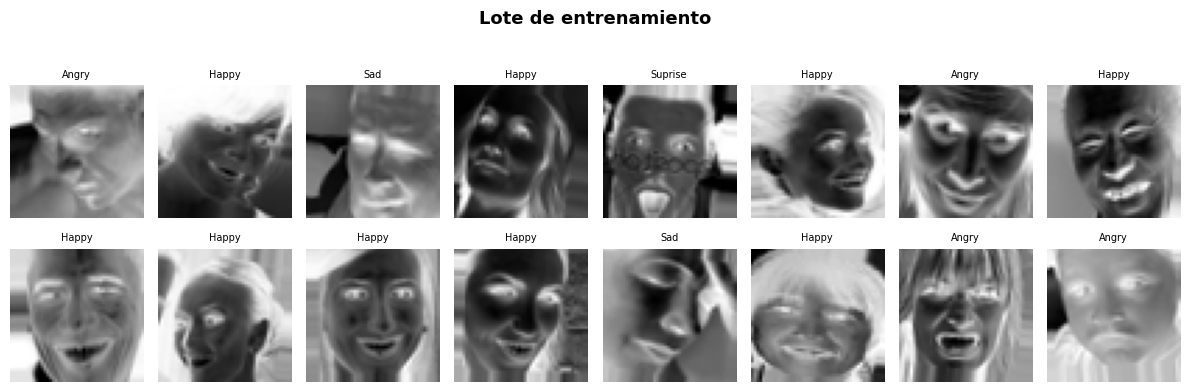

In [8]:
# primero pedimos un lote del generador de entrenamiento
X_batch, Y_batch = next(gen_train)

# obtengo el nombre de la clsae, por ejemplo -> 0: angry, 1: fear ...
idx_a_clase = {v: k for k, v in gen_train.class_indices.items()}

# representamos el lote para ver si las transformaciones se aplicaron
filas, columnas = 2, 8
fig, axes = plt.subplots(filas, columnas, figsize=(1.5 * columnas, 2 * filas))

for i in range(filas * columnas):
    ax = axes[i // columnas, i % columnas]
    ax.imshow(X_batch[i].reshape(TAMANO_IMG), cmap='gray_r')
    ax.set_title(idx_a_clase[np.argmax(Y_batch[i])], fontsize=7)
    ax.axis('off')

plt.suptitle('Lote de entrenamiento', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Implementación


Defino una función para entrenar el modelo y mostrar dos gráficas, una con la pérdida en train y ne validación y otra con el accuracy en train y en validación.

In [9]:
EPOCAS = 50


def entrenar_y_graficar(modelo, nombre_modelo):
    hist = modelo.fit(
        gen_train,
        epochs=EPOCAS,
        validation_data=gen_val,
        verbose=1
    )

    train_acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    epocas = list(range(1, len(val_acc) + 1))

    mejor_idx = int(np.argmax(val_acc))
    mejor_epoca = epocas[mejor_idx]
    mejor_val_acc = val_acc[mejor_idx]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='Train Loss', color='red', linewidth=2)
    plt.plot(hist.history['val_loss'], label='Val Loss', color='orange', linewidth=2, linestyle='--')
    plt.title(f'{nombre_modelo} - Loss')
    plt.xlabel('Época')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epocas, train_acc, label='Train Accuracy', color='green', linewidth=2)
    plt.plot(epocas, val_acc, label='Val Accuracy', color='blue', linewidth=2, linestyle='--')
    plt.scatter(mejor_epoca, mejor_val_acc, color='black', s=70, zorder=5, label=f'Mejor val_accuracy ({mejor_val_acc:.4f})')
    plt.annotate(
        f'epoca {mejor_epoca} | val_acc={mejor_val_acc:.4f}',
        (mejor_epoca, mejor_val_acc),
        textcoords='offset points',
        xytext=(12, 10),
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.8)
    )
    plt.title(f'{nombre_modelo} - Accuracy')
    plt.xlabel('Época')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'{nombre_modelo}')
    print(f'   mejor val_accuracy: {mejor_val_acc:.4f} ({mejor_val_acc*100:.2f}%) en la época {mejor_epoca}')

    return hist

Los modelos que se muestran a continuación son los q mejor resultado han obtenido de todos los que hemos probado, los cuales vamos a entrenar con más épocas para ver si sacamos más rendimiento.

## Modelo 1

- capas ocultas -> 32, 64, 128 MaXPool+Batch+Drop(0.25)
- Dropout 0.4
- capas densas -> 256 Flatten
- lr -> 0.001
- épocas -> 20
- kernel -> 5x5

In [10]:
def construir_modelo():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding='same', input_shape=(48,48,1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (5,5), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(128, (5,5), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])

    return modelo


Entreno el modelo y muestro sus gráficas

c:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 230s 176ms/step - accuracy: 0.3980 - loss: 1.4394 - val_accuracy: 0.4364 - val_loss: 1.3392
Epoch 2/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 137s 106ms/step - accuracy: 0.4834 - loss: 1.2301 - val_accuracy: 0.4154 - val_loss: 1.3269
Epoch 3/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 139s 108ms/step - accuracy: 0.5228 - loss: 1.1575 - val_accuracy: 0.5251 - val_loss: 1.1862
Epoch 4/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 135s 105ms/step - accuracy: 0.5499 - loss: 1.1126 - val_accuracy: 0.5368 - val_loss: 1.1505
Epoch 5/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 133s 103ms/step - accuracy: 0.5643 - loss: 1.0781 - val_accuracy: 0.5046 - val_loss: 1.3255
Epoch 6/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 133s 103ms/step - accuracy: 0.5765 - loss: 1.0540 - val_accuracy: 0.6054 - val_loss: 0.9720
Epoch 7/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 133s 103ms/step - accuracy: 0.5852 - loss: 1.0332 - val_accuracy: 0.6127 - val_loss: 0.9735
Epoch 8/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 135s 104ms/step - ac

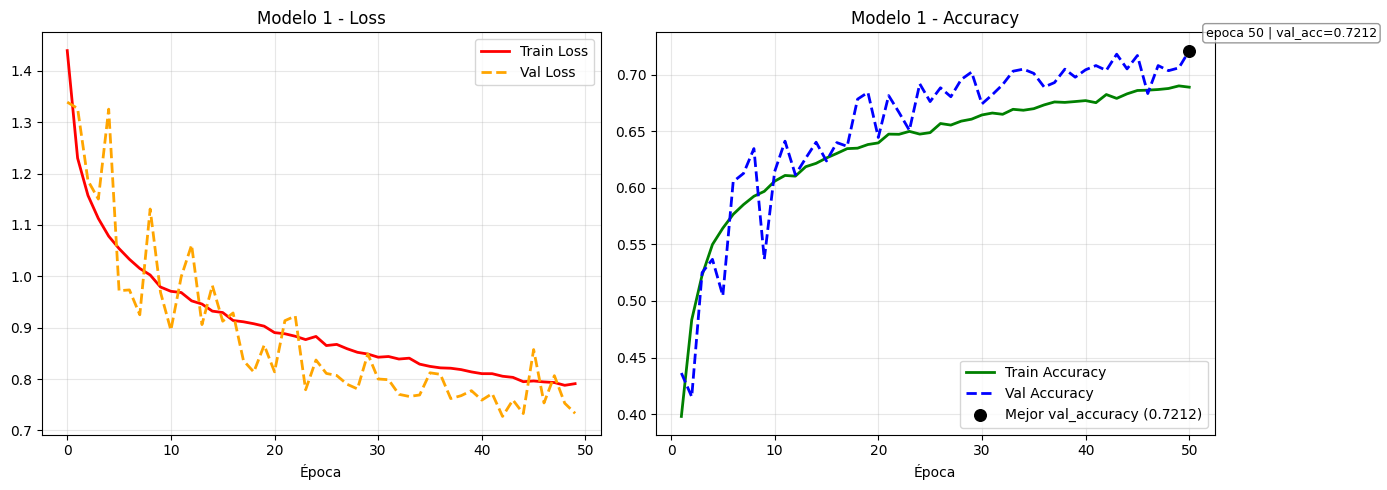

Modelo 1
   mejor val_accuracy: 0.7212 (72.12%) en la época 50


In [33]:
modelo1 = construir_modelo()
hist1 = entrenar_y_graficar(modelo1, 'Modelo 1')
modelo1.save('modelo1.h5')

## Modelo 2

- capas ocultas -> 32, 64, 128 Bath+MaxPool
- Dropout 0.5
- capas densas -> 256 flatten 
- lr -> 0.001
- épocas -> 20
- kernel -> 3x3

In [11]:
def construir_modelo2():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48,48,1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo

Entreno el modelo y muestro sus gráficas.

Epoch 1/50


c:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1293/1293 ━━━━━━━━━━━━━━━━━━━━ 109s 83ms/step - accuracy: 0.4018 - loss: 1.4382 - val_accuracy: 0.4691 - val_loss: 1.2980
Epoch 2/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 107s 82ms/step - accuracy: 0.5049 - loss: 1.1953 - val_accuracy: 0.5358 - val_loss: 1.1631
Epoch 3/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 107s 83ms/step - accuracy: 0.5497 - loss: 1.1078 - val_accuracy: 0.5640 - val_loss: 1.0992
Epoch 4/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 110s 85ms/step - accuracy: 0.5710 - loss: 1.0652 - val_accuracy: 0.5845 - val_loss: 1.0580
Epoch 5/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 146s 113ms/step - accuracy: 0.5837 - loss: 1.0382 - val_accuracy: 0.6056 - val_loss: 0.9950
Epoch 6/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 147s 113ms/step - accuracy: 0.5919 - loss: 1.0152 - val_accuracy: 0.6187 - val_loss: 0.9770
Epoch 7/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 127s 98ms/step - accuracy: 0.6013 - loss: 0.9993 - val_accuracy: 0.6295 - val_loss: 0.9362
Epoch 8/50
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 109s 84ms/step - accuracy: 0.6079 - 

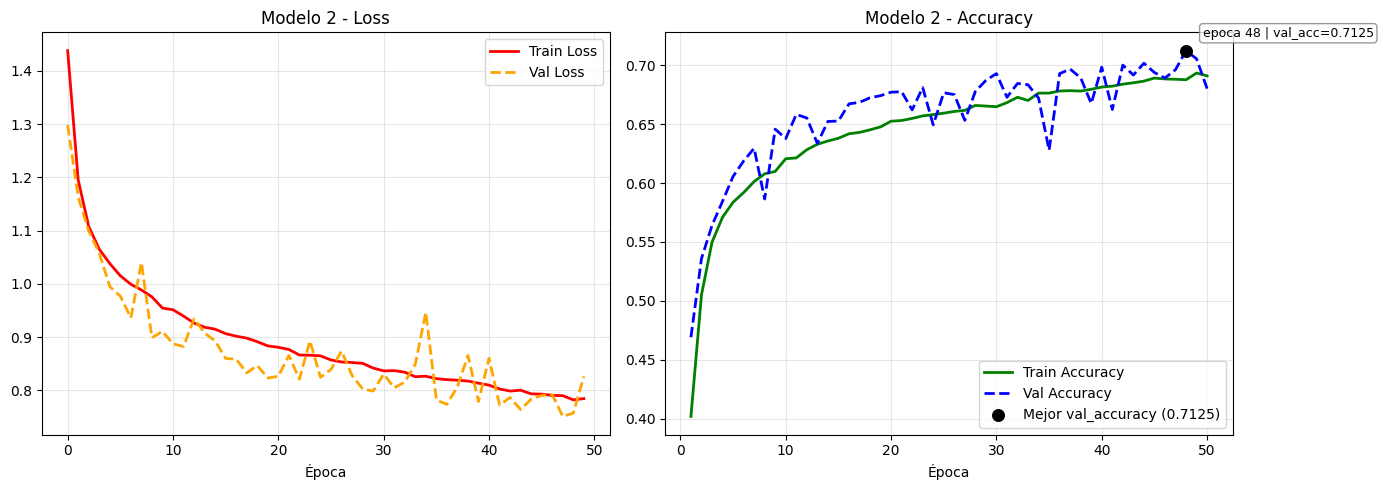

Modelo 2
   mejor val_accuracy: 0.7125 (71.25%) en la época 48


In [ ]:
modelo2 = construir_modelo2()
hist2 = entrenar_y_graficar(modelo2, 'Modelo 2')
modelo2.save('modelo2.h5')

# Evalucación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


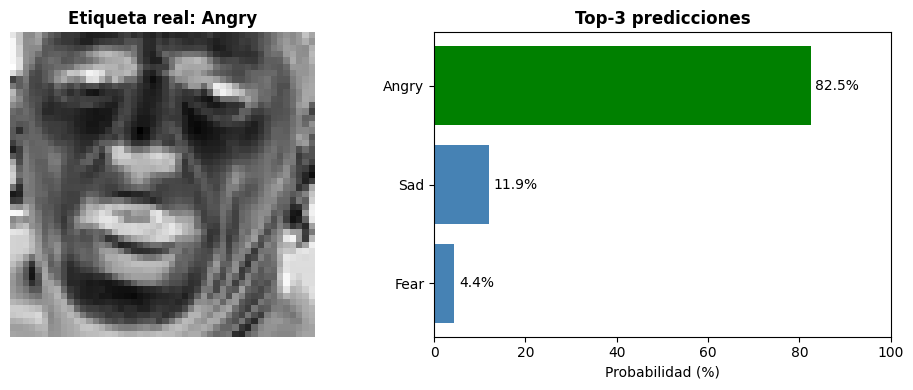

In [12]:
#cargo el modelo ganador que guarde previamente
modelo1 = tf.keras.models.load_model('modelo1.h5')

#mapeo índice → nombre de clase
idx_a_clase = {v: k for k, v in gen_test.class_indices.items()}

#pilllo una imagen real del generador de test
X_test_batch, Y_test_batch = next(gen_test)

#cogo la primera imagen del lote
imagen = X_test_batch[0]
etiqueta_real = idx_a_clase[np.argmax(Y_test_batch[0])]
prediccion = modelo1.predict(tf.expand_dims(imagen, 0))[0]

#otengo los índices ordenados de mayor a menor probabilidad
top3_indices = np.argsort(prediccion)[::-1][:3]

#muestro la imagen con sus top-3 predicciones
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(imagen.reshape(TAMANO_IMG), cmap='gray_r')
plt.title(f'Etiqueta real: {etiqueta_real}', fontsize=12, fontweight='bold')
plt.axis('off')
plt.subplot(1, 2, 2)
nombres_top3 = [idx_a_clase[i] for i in top3_indices]
probs_top3   = [prediccion[i] * 100 for i in top3_indices]
colores      = ['green' if nombres_top3[i] == etiqueta_real
                else 'steelblue' for i in range(3)]

bars = plt.barh(nombres_top3[::-1], probs_top3[::-1], color=colores[::-1])
plt.xlabel('Probabilidad (%)')
plt.title('Top-3 predicciones', fontsize=12, fontweight='bold')
plt.xlim(0, 100)

#etiquetas de porcentaje en las barras
for bar, prob in zip(bars, probs_top3[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{prob:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()



278/278 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step


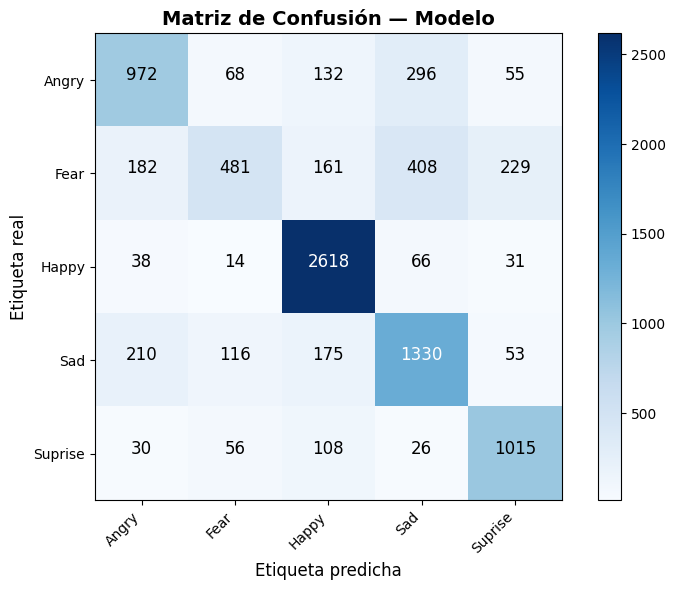

In [13]:
gen_test.reset()  # reiniciar el generador al principio
Y_pred_probs = modelo1.predict(gen_test, steps=math.ceil(gen_test.samples / TAMANO_LOTE))

#convertimos las probabilidades a clases
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_real = gen_test.classes

#ponemos los nombres de clases en orden y calculamos la matriz
nombres_clases = list(gen_test.class_indices.keys())
cm = confusion_matrix(Y_real, Y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión — Modelo', fontsize=14, fontweight='bold')
plt.colorbar()

tick_marks = np.arange(len(nombres_clases))
plt.xticks(tick_marks, nombres_clases, rotation=45, ha='right')
plt.yticks(tick_marks, nombres_clases)

#para ver los valores dentro de cada celda
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, str(cm[i, j]),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black',
             fontsize=12)

plt.ylabel('Etiqueta real', fontsize=12)
plt.xlabel('Etiqueta predicha', fontsize=12)
plt.tight_layout()
plt.show()


### Respuestas a las preguntas propuestas

**¿El modelo alcanzó entrenamiento óptimo?**

La respuesta corta sería no del todo. En las curvas de las graficas podemos ver que el modelo aprende de forma consistente durante las primeras 25 épocas, donde tanto la train_acc como la val_acc suben de forma practicamente paralela sin separarse significativamente, lo que indica que no hay de overfitting. A partir de la época 25 ya ambas curvas se aplanan un poco más que antes, aunque no diríamos que el modelo entra en una fase de convergencia total, porque aunque las mejoras parece que siguen siendo mínimas, el mejor val_acc que conseguimos fue de 0.7212 en la época 50, es un resultado que es cierto que es practicamente igual al resultado obtenido en épocas anteriores pero quiza con más epocas llega a mejorar, aun asés también es cierto que el modelo practicamente ha llegado a su techo con esta arquitectura y configuración.

**¿Qué revela la matriz de confusión sobre la generalización del modelo?**

La matriz es curiosas ya que nos muestra una generalización muy desigual según la clase. El modelo predice muy bien para Happy (94.6%) y Suprise (82.2%), expresiones con rasgos visuales muy diferenciales como son: la sonrisa o la boca abierta. En cambio generaliza mal para Fear (32.9%), cuyas características visuales se pueden confundir en muchos casos con las de Sad, ya que encontramos 408 confusiones y Suprise, 229 confusiones. Angry y Sad también se confunden frecuentemente entre sí con 296 y 210 casos, también a causa de compartir rasgos faciales similares. Esta asimetría que vemos en la matriz de correlación indica que el modelo aprendió a detectar rasgos faciales distintivos pero no ha conseguido separar correctamente las expresiones negativas, que parece que son las más ambiguas visualmente.

**¿Cómo impactó el preprocesamiento en el rendimiento?**

El preprocesamiento tuvo un impacto bastante directo y decisivo en el rendimiento del modelo. En la configuración inicial que hicimos aplicamos un augmentation basado en talleres propuestos vistos en clase con los siguientes valores: rotación de ±30°, desplazamientos de ±25% y zoom entre 50% y 150%. Con esta configuración los mejores modelos no conseguían pasar 55-60% de val_acc independientemente de los cambios arquitectónicos que hacíamos. Al analizar el problema vimos que el zoom de 0.5 podía reducir la cara al 50% del frame dejando la mitad de la imagen como fondo vacío, y que una rotación de ±30° podía llegar a cortar frente y mentón en imágenes de 48×48 que ya de por si son pequeñas. El modelo estaba aprendiendo con imágenes donde los rasgos faciales clave eran frecuentemente irreconocibles. Tras corregirlo a valores más conservadores, como son: zoom 90-110%, rotación ±10%, desplazamiento ±10%. Los modelos mejoraron hasta el 70%, una ganancia de 10 puntos sin modificar la arquitectura. Esto nos demostró que para imágenes pequeñas de 48×48 un augmentation demasiado agresivo como al principio borrá información facial útil y perjudica el aprendizaje más de lo que lo beneficia.